In [11]:
import re
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
import numpy as np


def cfc_1000_filter(signal, time):
    signal = np.asarray(signal)
    time = np.asarray(time)

    dt = np.mean(np.diff(time))  # sampling interval
    cfc = 1000  # CFC 1000
    wd = 2 * np.pi * cfc / 0.6 * 1.25
    wa = np.tan(wd * dt / 2.0)
    a0 = wa**2 / (1 + wa**2 + np.sqrt(2) * wa)
    a1 = 2 * a0
    a2 = a0
    b1 = -2 * (wa**2 - 1) / (1 + wa**2 + np.sqrt(2) * wa)
    b2 = (-1 + np.sqrt(2) * wa - wa**2) / (1 + wa**2 + np.sqrt(2) * wa)
    y = np.zeros_like(signal)
    for i in range(2, len(signal)):
        y[i] = (
            a0 * signal[i]
            + a1 * signal[i - 1]
            + a2 * signal[i - 2]
            + b1 * y[i - 1]
            + b2 * y[i - 2]
        )
    x = y.copy()
    y = np.zeros_like(signal)
    for i in range(len(signal) - 3, -1, -1):
        y[i] = a0 * x[i] + a1 * x[i + 1] + a2 * x[i + 2] + b1 * y[i + 1] + b2 * y[i + 2]

    return y

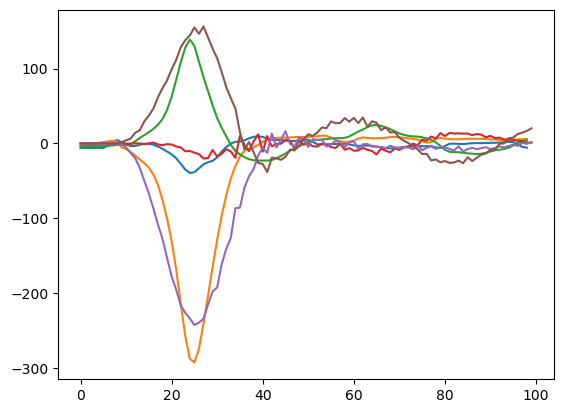

In [ ]:
num_pattern = r"[+-]?\d+\.\d+E[+-]?\d+"
time_pattern = r"at time\s*([+-]?\d+\.\d+E[+-]?\d+)"

accels = []
rot_accels = []
current_time = None

with open("nodout") as f:
    nodout = f.readlines()

for i, step in enumerate(nodout):
    time_match = re.search(time_pattern, step)
    if time_match:
        current_time = float(time_match.group(1))
    if "x-disp" in step:
        data_line = nodout[i + 1]
        nums = re.findall(num_pattern, data_line)
        if len(nums) >= 9 and current_time is not None:
            nums = list(map(float, nums))
            accels.append((current_time, *nums[6:9]))
    elif "x-rot" in step:
        data_line = nodout[i + 1]
        nums = re.findall(num_pattern, data_line)
        if len(nums) >= 9 and current_time is not None:
            nums = list(map(float, nums))
            rot_accels.append((current_time, *nums[6:9]))

accel_df = pd.DataFrame(accels, columns=["Time", "X", "Y", "Z"]).loc[3185:3284]
rot_accel_df = pd.DataFrame(rot_accels, columns=["Time", "X", "Y", "Z"]).loc[3185:3284]

lit_x = pd.read_csv("literature_X.csv", header=None)
lit_y = pd.read_csv("literature_Y.csv", header=None)
lit_z = pd.read_csv("literature_Z.csv", header=None)

plt.plot(range(len(lit_x[1])), lit_x[1])
plt.plot(range(len(lit_y[1])), lit_y[1])
plt.plot(range(len(lit_z[1])), lit_z[1])

plt.plot(range(len(accel_df["X"])), accel_df["X"] * -101)
plt.plot(range(len(accel_df["Y"])), accel_df["Y"] * -101)
plt.plot(range(len(accel_df["Z"])), accel_df["Z"] * 101)